In [51]:
#Importing all the required libraries and data for Hypothesis Test

from os.path import basename, exists
import numpy as np
import thinkstats2
import thinkplot
import random

def download(url):
    
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)

# downloading all the required data  

download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkstats2.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/thinkplot.py")

In [53]:
# Import additional functions required to get PregLength Test and Permutations
import first
import warnings

#This will be used to avoid warnings for pandas functions 
warnings.simplefilter(action='ignore',category=FutureWarning)

live, firsts, others = first.MakeFrames()
data = firsts.prglngth.values, others.prglngth.values

In [54]:
# Chi Squared test for pregnant length

class PregLengthTest(thinkstats2.HypothesisTest):

    def MakeModel(self):
        firsts, others = self.data
        self.n = len(firsts)
        self.pool = np.hstack((firsts, others))

        pmf = thinkstats2.Pmf(self.pool)
        self.values = range(35, 44)
        self.expected_probs = np.array(pmf.Probs(self.values))

    def RunModel(self):
        np.random.shuffle(self.pool)
        data = self.pool[:self.n], self.pool[self.n:]
        return data
    
    def TestStatistic(self, data):
        firsts, others = data
        stat = self.ChiSquared(firsts) + self.ChiSquared(others)
        return stat

    def ChiSquared(self, lengths):
        hist = thinkstats2.Hist(lengths)
        observed = np.array(hist.Freqs(self.values))
        expected = self.expected_probs * len(lengths)
        stat = sum((observed - expected)**2 / expected)
        return stat

In [55]:
data = firsts.prglngth.values, others.prglngth.values
ht = PregLengthTest(data)
p_value = ht.PValue()
print('p-value =', p_value)
print('actual =', ht.actual)
print('ts max =', ht.MaxTestStat())

p-value = 0.0
actual = 101.50141482893264
ts max = 24.318796017969824


In [56]:
class DiffMeansPermute(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        group1, group2 = data
        test_stat = abs(group1.mean() - group2.mean())
        return test_stat

    def MakeModel(self):
        group1, group2 = self.data
        self.n, self.m = len(group1), len(group2)
        self.pool = np.hstack((group1, group2))

    def RunModel(self):
        np.random.shuffle(self.pool)
        data = self.pool[:self.n], self.pool[self.n:]
        return data

In [59]:
class CorrelationPermute(thinkstats2.HypothesisTest):

    def TestStatistic(self, data):
        xs, ys = data
        test_stat = abs(thinkstats2.Corr(xs, ys))
        return test_stat

    def RunModel(self):
        xs, ys = self.data
        xs = np.random.permutation(xs)
        return xs, ys

### Exercise 9.1

# As sample size increases, the power of a hypothesis test increases, 
# which means it is more likely to be positive if the effect is real. 
# Conversely, as sample size decreases, the test is less likely to be positive even if the effect is real.

In [62]:
def RunTests(live, iters=1000):
    """Runs the tests from Chapter 9 with a subset of the data.

    live: DataFrame
    iters: how many iterations to run
    """
    n = len(live)
    firsts = live[live.birthord == 1]
    others = live[live.birthord != 1]

    # compare pregnancy lengths
    data = firsts.prglngth.values, others.prglngth.values
    ht = DiffMeansPermute(data)
    p1 = ht.PValue(iters=iters)

    data = (firsts.totalwgt_lb.dropna().values,
            others.totalwgt_lb.dropna().values)
    ht = DiffMeansPermute(data)
    p2 = ht.PValue(iters=iters)

    # test correlation
    live2 = live.dropna(subset=['agepreg', 'totalwgt_lb'])
    data = live2.agepreg.values, live2.totalwgt_lb.values
    ht = CorrelationPermute(data)
    p3 = ht.PValue(iters=iters)

    # compare pregnancy lengths (chi-squared)
    data = firsts.prglngth.values, others.prglngth.values
    ht = PregLengthTest(data)
    p4 = ht.PValue(iters=iters)

    print('%d\t%0.2f\t%0.2f\t%0.2f\t%0.2f' % (n, p1, p2, p3, p4))

In [65]:
# Solution

n = len(live)
for _ in range(7):
    sample = thinkstats2.SampleRows(live, n)
    RunTests(sample)
    n //= 2

9148	0.18	0.00	0.00	0.00
4574	0.59	0.00	0.00	0.00
2287	0.17	0.44	0.03	0.00
1143	0.33	0.03	0.03	0.00
571	0.79	0.04	0.58	0.60
285	0.19	0.35	0.79	0.93
142	0.06	0.24	0.78	0.03


## Excercise 10.1
### Read the BRFSS data and extract heights and log weights.

In [69]:
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/brfss.py")
download("https://github.com/AllenDowney/ThinkStats2/raw/master/code/CDBRFS08.ASC.gz")

In [70]:
import brfss

df = brfss.ReadBrfss(nrows=None)
df = df.dropna(subset=['htm3', 'wtkg2'])
heights, weights = df.htm3, df.wtkg2
log_weights = np.log10(weights)

In [71]:
# Estimate intercept and slope.

inter, slope = thinkstats2.LeastSquares(heights, log_weights)
inter, slope

(0.9930804163932894, 0.005281454169417767)

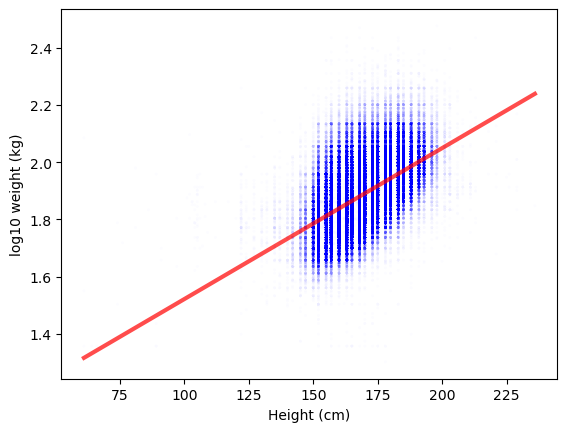

In [72]:
# Make a scatter plot of the data and show the fitted line.

thinkplot.Scatter(heights, log_weights, alpha=0.01, s=5)
fxs, fys = thinkstats2.FitLine(heights, inter, slope)
thinkplot.Plot(fxs, fys, color='red')
thinkplot.Config(xlabel='Height (cm)', ylabel='log10 weight (kg)', legend=False)

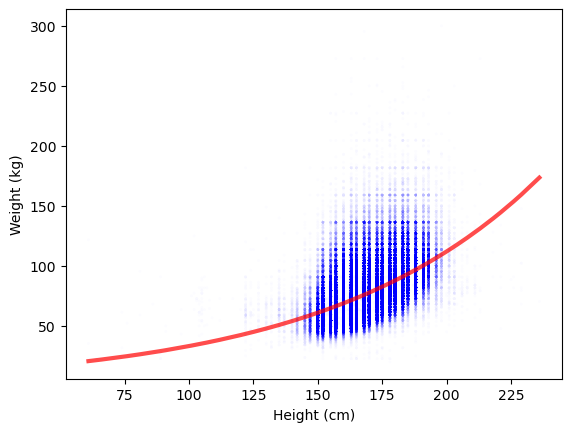

In [73]:
# Make the same plot but apply the inverse transform to show weights on a linear (not log) scale.

thinkplot.Scatter(heights, weights, alpha=0.01, s=5)
fxs, fys = thinkstats2.FitLine(heights, inter, slope)
thinkplot.Plot(fxs, 10**fys, color='red')
thinkplot.Config(xlabel='Height (cm)', ylabel='Weight (kg)', legend=False)

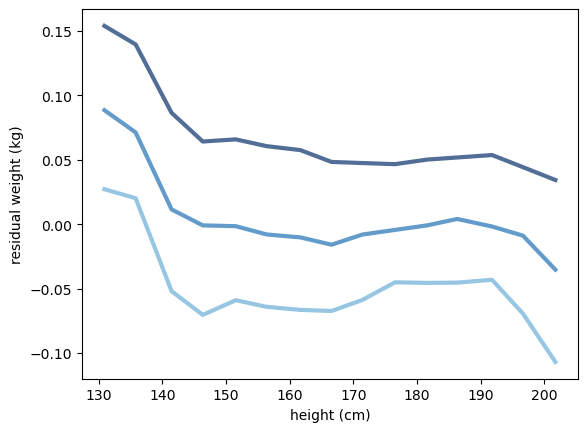

In [74]:
# Plot percentiles of the residuals.

# The lines are flat over most of the range, 
# indicating that the relationship is linear.

# The lines are mostly parallel, indicating 
# that the variance of the residuals is the 
# same over the range.

res = thinkstats2.Residuals(heights, log_weights, inter, slope)
df['residual'] = res

bins = np.arange(130, 210, 5)
indices = np.digitize(df.htm3, bins)
groups = df.groupby(indices)

means = [group.htm3.mean() for i, group in groups][1:-1]
cdfs = [thinkstats2.Cdf(group.residual) for i, group in groups][1:-1]

thinkplot.PrePlot(3)
for percent in [75, 50, 25]:
    ys = [cdf.Percentile(percent) for cdf in cdfs]
    label = '%dth' % percent
    thinkplot.Plot(means, ys, label=label)
    
thinkplot.Config(xlabel='height (cm)', ylabel='residual weight (kg)', legend=False)

In [75]:
#Compute correlation

rho = thinkstats2.Corr(heights, log_weights)
rho

0.531728260598403

In [76]:
# Compute coefficient of determination

r2 = thinkstats2.CoefDetermination(log_weights, res)
r2


0.2827349431187015

In [77]:

# Compute Std(res), the RMSE of predictions that do use height.
std_res = thinkstats2.Std(res)
std_res

0.08740777080416452

In [78]:
# Compute Std(ys), which is the RMSE of predictions that don't use height.
std_ys = thinkstats2.Std(log_weights)
std_ys


0.10320725030003608

In [79]:
# How much does height information reduce RMSE?

1 - std_res / std_ys

0.1530849765877934

In [80]:
# Use resampling to compute sampling distributions for inter and slope.

t = []
for _ in range(100):
    sample = thinkstats2.ResampleRows(df)
    estimates = thinkstats2.LeastSquares(sample.htm3, np.log10(sample.wtkg2))
    t.append(estimates)

inters, slopes = zip(*t)

{'xscale': 'linear', 'yscale': 'linear'}

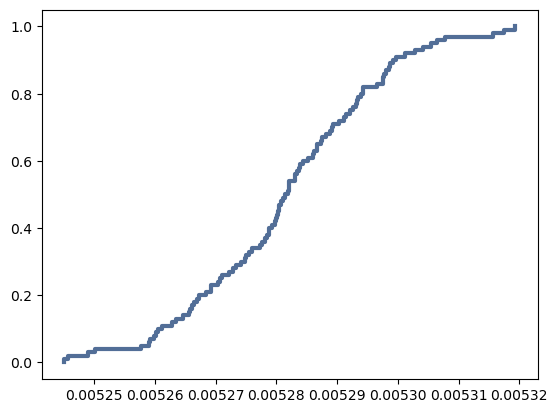

In [82]:
# Plot the sampling distribution of slope.

cdf = thinkstats2.Cdf(slopes)
thinkplot.Cdf(cdf)

In [83]:
# Compute the p value of the slope
pvalue = cdf[0]
pvalue

0

In [84]:
# Compute the 90% confidence interval of the slope.

ci = cdf.Percentile(5), cdf.Percentile(95)
ci

(0.005257684072856559, 0.005305498451051175)